In [12]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import product
import random
from tqdm import tqdm
import ast
from collections import OrderedDict
from pprint import pprint

MAX_SAMPLES = 100_000

def gen_directed_graphs(n=4, m=15):
    graphs = defaultdict(list)

    for i in range(n):
        G = nx.DiGraph()  # Create a directed graph
        nodes = [j for j in range(m)]  # Create a list of nodes
        # edges = list(zip(nodes[:-1], nodes[1:]))  # Create edges between consecutive nodes

        # make sure the edge is not a loop
        # edges = [(random.choice(nodes), random.choice(nodes)) for _ in range(m)]
        used_nodes = set()
        edges = []

        while len(edges) < m:
            pos1 = random.choice(nodes)
            pos2 = random.choice(nodes)

            if (pos1, pos2) not in edges and (pos2, pos1) not in edges and pos1 != pos2:
                edges.append((pos1, pos2))
                used_nodes.add(pos1)
                used_nodes.add(pos2)

                # If we're about to finish but haven't used all nodes,
                # reject this attempt and start over
                remaining_edges = m - len(edges)
                unused_nodes = set(nodes) - used_nodes
                if remaining_edges < len(unused_nodes):
                    edges = []
                    used_nodes = set()

        # filter out edges from edges that loop
        # edges = [(u, v) for u, v in edges if u != v]
        
        # Assign random directions to edges
        random_edges = set()

        for u, v in edges:
            if random.choice([True, False]):  # Randomly decide the direction
                random_edges.add((u, v))
            else:
                random_edges.add((v, u))

        random_edges = list(random_edges)
        
        
        G.add_edges_from(random_edges)  # Add edges with random directions

        if(nx.number_weakly_connected_components(G) > 1):
            
            main_component = max(nx.weakly_connected_components(G), key=len)  # Find the largest connected component
            print(nx.number_weakly_connected_components(G))
            print(f"Main connected component: {main_component}")
            # iterate through weakly connected components aside the main one
            for component in [c for c in nx.weakly_connected_components(G) if c != main_component]:
                num_of_connections = random.randint(1, len(component))
                print(f"Weakly connected component: {component}")
                # choose random nodes from the component based on num_of_connections
                random_nodes = random.sample(sorted(component), num_of_connections)
                # connect each node from random_nodes to random node from the main component
                for node in random_nodes:
                    G.add_edge(node, random.choice(list(main_component)))

        else:
            print("one component")

        graphs[i] = G.to_undirected()
        
    return graphs

def add_enabling(chains):
    n = len(chains)
    
    for chain_id in range(n-1):
        G = chains[chain_id]
        
        for edge in G.edges():
            if random.random() < 0.5:

                number_of_groups = random.randint(1,3)
                group_conditions = []

                for x in range(number_of_groups):

                    num_deps = random.randint(1, 3)
                    
                    later_chains = list(range(chain_id + 1, n))
                    selected_chains = random.sample(later_chains, min(num_deps, len(later_chains)))
                    
                    enabling_conditions = []

                    for enabling_chain in selected_chains:
                        enabling_G = chains[enabling_chain]
                        enabling_node = random.choice(list(enabling_G.nodes()))
                        enabling_conditions.append({'automata_id':enabling_chain,'node_id':enabling_node})

                    group_conditions.append(enabling_conditions)
                
                G.edges[edge]['enabling'] = group_conditions if len(group_conditions) > 0 else None
    
    return chains

def get_sample(vector, graphs):
    num_states = len(graphs[0].nodes())
    vec = list(vector)  # [1,2,3,4]
    for i in range(num_states):
        if vec[0] != i:
            yield vec, i

def filter_unique_paths(paths_lst):
    if not paths_lst:
        return []
    
    # Keep track of which paths should be excluded
    paths_to_exclude = set()
    
    # For each path, check if it contains any shorter path as a subsequence
    for path in paths_lst:
        for other_path in paths_lst:
            # Skip if same path or if other_path is not shorter
            if path == other_path or len(other_path) >= len(path):
                continue
                
            # Check if other_path is a subsequence of path
            j, k = 0, 0  # j for other_path, k for path
            while j < len(other_path) and k < len(path):
                if other_path[j] == path[k]:
                    j += 1
                k += 1
                
            # If other_path is a subsequence of path, exclude path
            if j == len(other_path):
                paths_to_exclude.add(tuple(path))
                break
    
    # Return all paths except those that contain shorter paths as subsequences
    return [path for path in paths_lst if tuple(path) not in paths_to_exclude]

def get_vectors(chains):
    states_per_chain = []
    iters = 0
    for chain_id in range(len(chains)):
        states_per_chain.append(list(chains[chain_id].nodes()))
        iters += 1
        if iters >= MAX_SAMPLES:
            break
    
    return list(product(*states_per_chain))

def solve(curr_states, target_node, graphs, orig_state_len, log=[], depth=0):
    '''
    Solves the problem of reaching target node from current state in graphs by returning the resulting state and log of steps.
    Parameters:
        curr_states: list of current states of automatas; LIST of INTEGERS
        target_node: target node; INTEGER
        graphs: list of graphs; LIST of networkx graphs
        log: list of log messages; LIST of STRINGS
        depth: depth of recursion; INTEGER
    Returns:
        out: states of automatas after solving or None if no solution; LIST of INTEGERS/None
            out: log: list of log messages; LIST of STRINGS
    '''
    curr_automata_id = orig_state_len - len(curr_states)
    indent = '-'*depth*2
    # log.append(f"{'-'*50}")
    curr_states_cpy = curr_states.copy()
    log.append(f"{indent}S {curr_states_cpy} TN {target_node}")
    # get all paths from current state to target node
    paths_lst = list(nx.all_simple_paths(graphs[0], curr_states_cpy[0], target_node))
    # check if a shorter path isn't already in a different longer path
    paths_lst = filter_unique_paths(paths_lst)
    log.append(f"{indent}PL {paths_lst}")
    
    # check if there is a path
    if len(paths_lst) == 0:
        log.append(f"{indent}NOPATH {curr_states} TN {target_node}")
        return None, log
    
    # check if current node equals target node
    if curr_states_cpy[0] == target_node:
        log.append(f"{indent}REND {curr_states_cpy}")
        return curr_states_cpy, log
    
    # path or paths exist and we are not in target node
    for path in paths_lst:
        log.append(f"{indent}PATH {curr_automata_id}: {path}")
        # projdu hrany po ceste (3-4), ziskam enabling
        curr_states_cpy = curr_states.copy()
        rules = graphs[0].get_edge_data(curr_states_cpy[0], path[1])
        # pokud neexistuje enabling, projdu edge
        log.append(f"{indent}RLS {rules}")
        if rules == {}:
            log.append(f"{indent}NOR {curr_states_cpy} TN {target_node}")
            # pokud má path jeden node, tak je to konec
            # log.append(f"{indent}{orig_state_len - len(curr_states_cpy)} {'U' if path[1] > curr_states_cpy[0] else 'D'}")

            log.append(f"{indent}{curr_automata_id}: {curr_states_cpy[0]} -> {path[1]}")
            curr_states_cpy[0] = path[1]
            log.append(f"{indent}NORCH {curr_states_cpy}")

            return solve(curr_states_cpy, target_node, graphs, orig_state_len, log, depth+1)

        # pokud existuje enabling, tak treba automat 1 ma byt ve stavu 2 a automat 2 ma byt ve stavu 3
        # prvni vyresime prvni pravidlo a pak druhe
        else:
            for rule_set in rules['enabling']:
                log.append(f"{indent}RS {rule_set}")

                curr_states_cpy = curr_states.copy()
                found = True

                for rule in sorted(rule_set, key=lambda x: x['automata_id']): # sorted znamena setrizene od nejvice zavisleho po nejmene
                    log.append(f"{indent}RULE {rule}")
                    idx = max(rule['automata_id'] - (orig_state_len - len(curr_states_cpy)), 0)
                    current_sub_state, log = solve(curr_states_cpy[idx:], rule['node_id'], graphs[idx:], orig_state_len, log, depth+1)

                    log.append(f"{indent}RCH {current_sub_state}")
                    if current_sub_state == None:
                        found = False
                        break
                    log.append(f"{indent}SUB {curr_states_cpy}")
                    curr_states_cpy[idx:] = current_sub_state
                    log.append(f"{indent}SUBCH {curr_states_cpy}")

                if found:
                    log.append(f"{indent}SUBF {curr_states_cpy}")
                    # log.append(f"{indent}{orig_state_len - len(curr_states_cpy)} {'U' if path[1] > curr_states_cpy[0] else 'D'}")

                    log.append(f"{indent}{curr_automata_id}: {curr_states_cpy[0]} -> {path[1]}")
                    curr_states_cpy[0] = path[1]
                    log.append(f"{indent}SUBSOLVED {curr_states_cpy}")
                    break
                else:
                    continue
            
            if found:
                return solve(curr_states_cpy, target_node, graphs, orig_state_len, log, depth+1)
            else:
                continue
    log.append(f"{indent}UNSOL {curr_states_cpy}")            
    return None, log

def process_graphs(graphs, states, target_nodes, orig_states_len, log=[]):
    log_cpy = log.copy()
    log_cpy.append("*"*30)
    states, log_cpy = solve(states, target_nodes[-1], graphs, orig_states_len, log=log_cpy)

    if len(graphs) == 1:
        return states, target_nodes, log_cpy

    if states is not None:
        log = log_cpy
        found = False
        rnd_target_nodes = [tn for tn in graphs[0].nodes() if tn != states[1]]
        random.shuffle(rnd_target_nodes)
        for i in rnd_target_nodes:
            target_nodes_cpy = target_nodes.copy()
            target_nodes_cpy.append(i)
            state_tmp, target_nodes_cpy, log_tmp = process_graphs(graphs[1:], states[1:], target_nodes_cpy, orig_states_len, log)
            if state_tmp is None:
                continue
            else:
                found = True
                log = log_tmp
                target_nodes = target_nodes_cpy
                states[1:] = state_tmp
                break

        if not found:
            states = None

    return states, target_nodes, log

In [13]:
graphs = add_enabling(gen_directed_graphs(n=8, m=12))

one component
2
Main connected component: {0, 1, 3, 4, 6, 9, 11}
Weakly connected component: {2, 5, 7, 8, 10}
one component
2
Main connected component: {0, 1, 2, 3, 4, 5, 7, 9, 10, 11}
Weakly connected component: {8, 6}
2
Main connected component: {0, 1, 2, 5, 6, 7, 8, 9, 10}
Weakly connected component: {3, 11, 4}
2
Main connected component: {0, 2, 3, 4, 5, 6, 7, 8, 9, 10}
Weakly connected component: {1, 11}
one component
one component


0


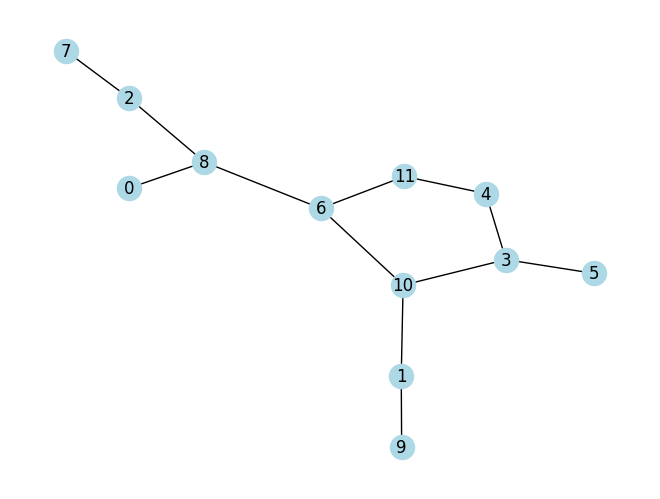

1


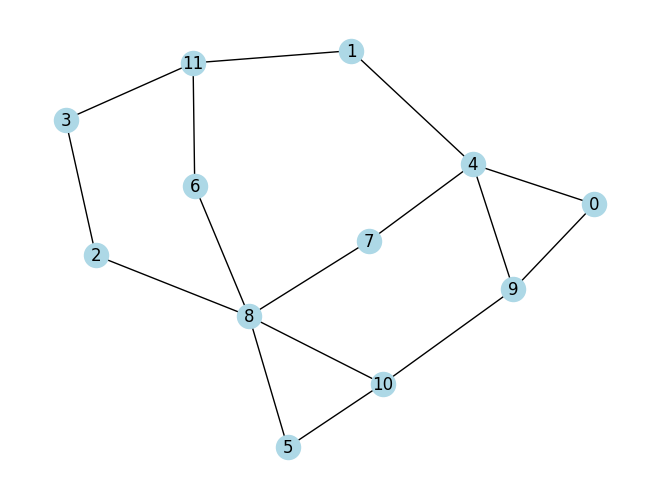

2


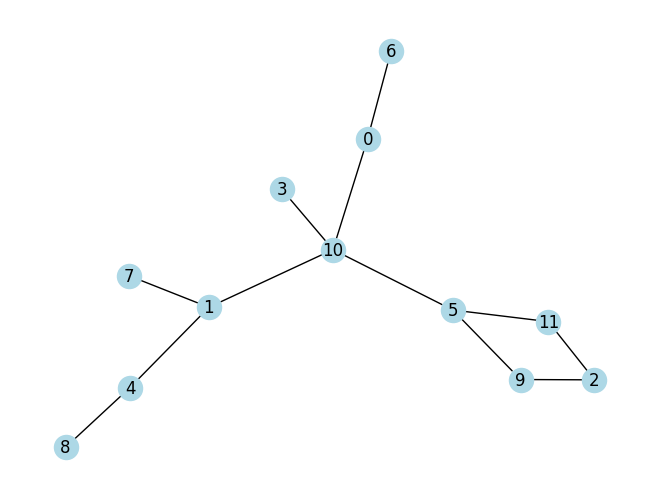

3


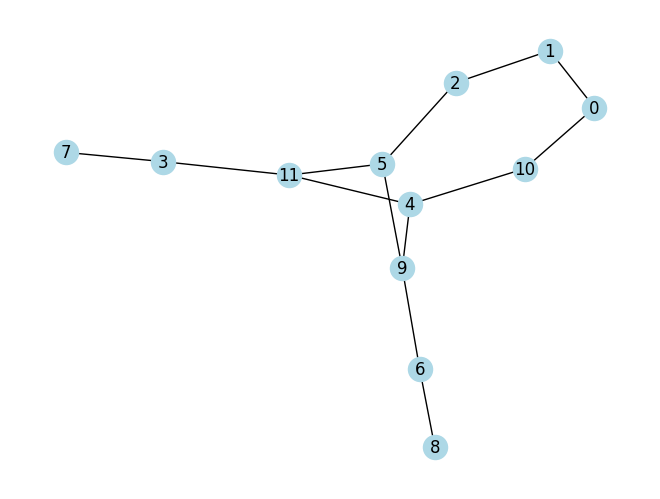

4


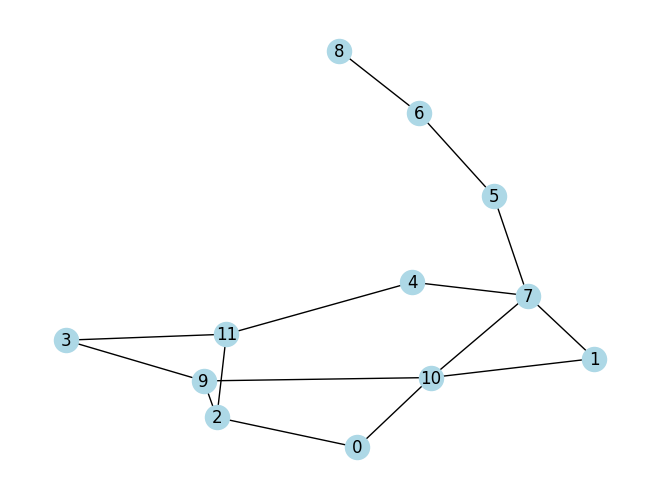

5


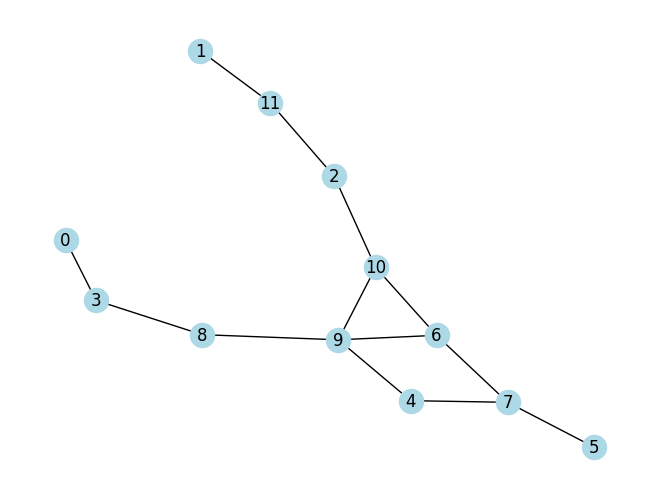

6


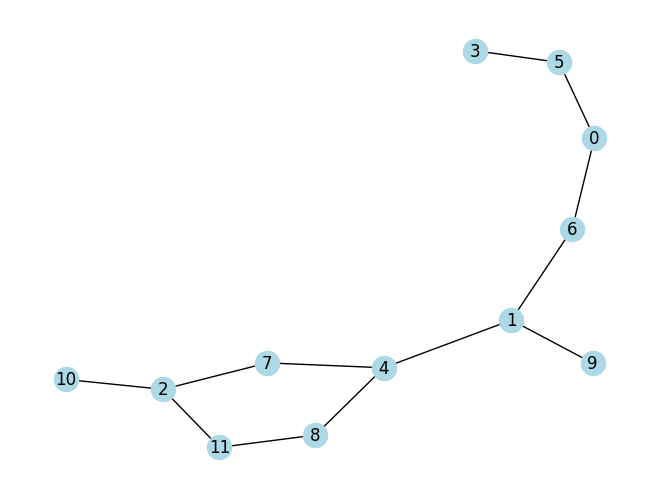

7


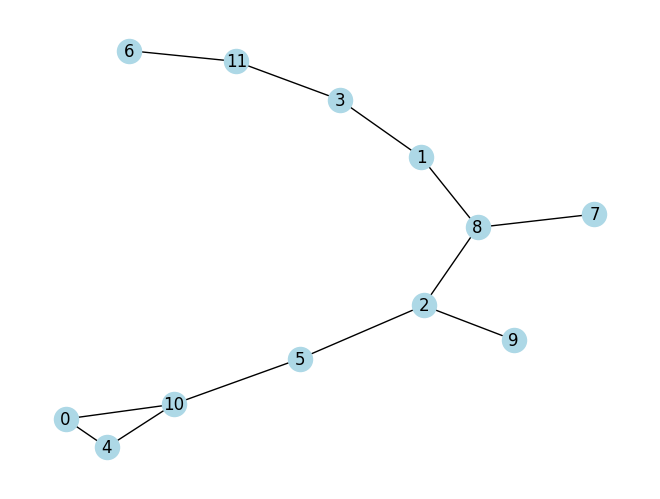

In [14]:
for i in range(len(graphs)):
    print(i)
    nx.draw(graphs[i], with_labels=True, node_color='lightblue', arrows=True)
    plt.show()

In [15]:
for chain_id in range(len(graphs)):
    print(f"\nChain {chain_id}:")
    G = graphs[chain_id]
    for edge in G.edges(data=True):
        print(f"Edge {edge[0]} -> {edge[1]}: {edge[2]}")



Chain 0:
Edge 2 -> 7: {}
Edge 2 -> 8: {'enabling': [[{'automata_id': 6, 'node_id': 5}]]}
Edge 4 -> 3: {'enabling': [[{'automata_id': 5, 'node_id': 2}, {'automata_id': 6, 'node_id': 1}], [{'automata_id': 6, 'node_id': 10}, {'automata_id': 5, 'node_id': 9}, {'automata_id': 4, 'node_id': 3}], [{'automata_id': 2, 'node_id': 8}, {'automata_id': 5, 'node_id': 0}]]}
Edge 4 -> 11: {'enabling': [[{'automata_id': 2, 'node_id': 7}, {'automata_id': 1, 'node_id': 4}, {'automata_id': 4, 'node_id': 7}]]}
Edge 3 -> 5: {}
Edge 3 -> 10: {'enabling': [[{'automata_id': 1, 'node_id': 6}, {'automata_id': 2, 'node_id': 5}, {'automata_id': 7, 'node_id': 9}], [{'automata_id': 3, 'node_id': 5}, {'automata_id': 4, 'node_id': 6}, {'automata_id': 2, 'node_id': 7}], [{'automata_id': 5, 'node_id': 2}]]}
Edge 11 -> 6: {'enabling': [[{'automata_id': 4, 'node_id': 4}, {'automata_id': 5, 'node_id': 11}], [{'automata_id': 7, 'node_id': 5}, {'automata_id': 2, 'node_id': 1}, {'automata_id': 3, 'node_id': 9}]]}
Edge 6 -> 1

In [16]:
vecs = get_vectors(graphs)
print(len(vecs))
print(vecs[0])

429981696
(2, 9, 8, 0, 9, 9, 8, 4)


In [17]:
vecs = vecs[:MAX_SAMPLES]
print(len(vecs))

100000


In [18]:
id_2_vec = {}
vec_2_id = {}
for i, comb in tqdm(enumerate(vecs)):
    id_2_vec[i] = comb
    vec_2_id[comb] = i

100000it [00:00, 2083908.76it/s]


In [19]:
indexes = list(range(len(vecs)))
samples = []

In [20]:
for i in get_sample(vecs[0], graphs):
    print(f"input vec: {i}")
    states, log_cpy = solve(i[0], i[1], list(graphs.values()), len(i[0]))
    pprint(log_cpy)
    break

input vec: ([2, 9, 8, 0, 9, 9, 8, 4], 0)
['S [2, 9, 8, 0, 9, 9, 8, 4] TN 0',
 'PL [[2, 8, 0]]',
 'PATH 0: [2, 8, 0]',
 "RLS {'enabling': [[{'automata_id': 6, 'node_id': 5}]]}",
 "RS [{'automata_id': 6, 'node_id': 5}]",
 "RULE {'automata_id': 6, 'node_id': 5}",
 '--S [8, 4] TN 5',
 '--PL [[8, 4, 1, 6, 0, 5]]',
 '--PATH 6: [8, 4, 1, 6, 0, 5]',
 "--RLS {'enabling': [[{'automata_id': 7, 'node_id': 9}], [{'automata_id': 7, "
 "'node_id': 7}]]}",
 "--RS [{'automata_id': 7, 'node_id': 9}]",
 "--RULE {'automata_id': 7, 'node_id': 9}",
 '----S [4] TN 9',
 '----PL [[4, 10, 5, 2, 9]]',
 '----PATH 7: [4, 10, 5, 2, 9]',
 '----RLS {}',
 '----NOR [4] TN 9',
 '----7: 4 -> 10',
 '----NORCH [10]',
 '------S [10] TN 9',
 '------PL [[10, 5, 2, 9]]',
 '------PATH 7: [10, 5, 2, 9]',
 '------RLS {}',
 '------NOR [10] TN 9',
 '------7: 10 -> 5',
 '------NORCH [5]',
 '--------S [5] TN 9',
 '--------PL [[5, 2, 9]]',
 '--------PATH 7: [5, 2, 9]',
 '--------RLS {}',
 '--------NOR [5] TN 9',
 '--------7: 5 -> 2',


In [21]:
total = 0

error_samples = []
logs = []
for i in tqdm(indexes):
    for sample in get_sample(vecs[i], graphs):
        try:
            total += 1

            in_states = sample[0]
            in_target_nodes = [sample[1]]

            states, target_nodes, sample_log = process_graphs(list(graphs.values()), in_states, in_target_nodes, len(in_states))
                
            if states is not None:
                logs.append({'sample': sample, 'target_nodes': target_nodes, 'log': sample_log})  # Add this ONE sample list to the main list
        except Exception as e:
            continue

  0%|          | 112/100000 [13:20<198:23:35,  7.15s/it]


KeyboardInterrupt: 

In [22]:
print(f"Total: {total}")
print(f"Solved logs length: {len(logs)}")
print(f"Success rate: {round(len(logs)/total, 2)*100}%")
print(f"Unsolved rate: {round((total-len(logs))/total,2)*100}%")

Total: 1241
Solved logs length: 0
Success rate: 0.0%
Unsolved rate: 100.0%


In [ ]:
def parse_log(log, sample, target_nodes):
    dic = {}
    init_state = log[1]
    end_idx = init_state.index("]")
    init_state = init_state[2:end_idx+1]
    # Parse the string into a Python list using ast.literal_eval
    parsed_list = ast.literal_eval(init_state)
    # Create a dictionary with indices as keys and list values as values
    init_state_dict = {i: value for i, value in enumerate(parsed_list)}
    # Print the result
    dic['init_state'] = init_state_dict

    # get all indexes of ***
    start_idx = []
    for i in range(len(log)):
        if log[i].startswith("*"*30):
            start_idx.append(i+1)

    target_nodes_lst = []
    for tn in start_idx:
        target_nodes_lst.append(int(log[tn][log[tn].index("TN")+3:]))

    # Parse the string into a Python list using ast.literal_eval
    parsed_list = target_nodes_lst
    # Create a dictionary with indices as keys and list values as values
    parsed_target_states_dict = OrderedDict((i, value) for i, value in enumerate(parsed_list))

    dic['stack'] = parsed_target_states_dict
    
    path = []
    last_num_of_indents = 0
    # deep copy
    curr_states = {k: v for k, v in init_state_dict.items()}

    # path.append(f"START {sample[0]} TARGET {target_nodes}")

    # for item in log:

    #     curr_num_of_indents = item.count("-")

    #     if "PATH" in item:
    #         path.append(f"{item.replace('-', '')}")

    #     # if " U" in item or " D" in item:
    #     #     path.append(item)

    #     if "RS " in item:
    #         tmp = item.replace("-", "")
    #         rs = ast.literal_eval(item.split("RS ")[1])
    #         res_dic = {}
    #         for rule in rs:
    #             res_dic[rule['automata_id']] = rule['node_id']

    #         string = ""
    #         for key, value in res_dic.items():
    #             string += f"{key}: {value}, "
    #         string = string[:-2]
    #         path.append(f"RULESET [{string}]")

    #     if "RULE" in item:
    #         # path.append("TF")
    #         rule = ast.literal_eval(item.split("RULE ")[1])
    #         automata_id = rule['automata_id']
    #         node_id = rule['node_id']
    #         path.append(f"RULE {automata_id}: {node_id}")

    #     if "->" in item:
    #         tmp = item.replace("-", "")
    #         curr_states[int(tmp.split(":")[0])] = int(item.split("-> ")[1])
    #         path.append(f"MOVE {item.replace('--', '')} = {list(curr_states.values())}")

    path.append({"START": sample[0]})
    path.append({"TARGET": target_nodes})
    
    for item in log:

        if "PATH" in item:
            automata_id = int(item.split("PATH ")[1].split(":")[0])
            path.append({"PATH": {automata_id: ast.literal_eval(item.split(": ")[1])}})

        # if " U" in item or " D" in item:
        #     path.append(item)

        if "RS " in item:
            tmp = item.replace("-", "")
            rs = ast.literal_eval(item.split("RS ")[1])
            res_dic = {}
            for rule in rs:
                res_dic[rule['automata_id']] = rule['node_id']

            string = ""
            for key, value in res_dic.items():
                string += f"{key}: {value}, "
            string = string[:-2]
            path.append({"RULESET": res_dic})

        if "RULE" in item:
            # path.append("TF")
            rule = ast.literal_eval(item.split("RULE ")[1])
            automata_id = rule['automata_id']
            node_id = rule['node_id']
            path.append({"RULE": {automata_id: node_id}})

        if "->" in item:
            tmp = item.replace("-", "")
            curr_states[int(tmp.split(":")[0])] = int(item.split("-> ")[1])
            path.append({"MOVE": {int(tmp.split(":")[0]): ({int(item.split(": ")[1].split(" ->")[0]): int(item.split("-> ")[1])}, list(curr_states.values()))}})


    dic['path'] = path

    return dic

In [ ]:
paths = []

for log in tqdm(logs):
    dict_of_path = parse_log(log['log'], sample=log['sample'], target_nodes=log['target_nodes'])
    paths.append(dict_of_path)

len(paths)

100%|██████████| 6480/6480 [00:02<00:00, 3190.75it/s]


6480

In [ ]:
paths[-1]['path'] # 50 000

[{'START': [5, 5, 3, 1]},
 {'TARGET': [4, 4, 1, 3]},
 {'PATH': {0: [5, 3, 4]}},
 {'RULESET': {1: 2}},
 {'RULE': {1: 2}},
 {'PATH': {1: [5, 3, 4, 2]}},
 {'MOVE': {1: ({5: 3}, [5, 3, 3, 1])}},
 {'PATH': {1: [3, 4, 2]}},
 {'MOVE': {1: ({3: 4}, [5, 4, 3, 1])}},
 {'PATH': {1: [4, 2]}},
 {'MOVE': {1: ({4: 2}, [5, 2, 3, 1])}},
 {'MOVE': {0: ({5: 3}, [3, 2, 3, 1])}},
 {'PATH': {0: [3, 4]}},
 {'MOVE': {0: ({3: 4}, [4, 2, 3, 1])}},
 {'PATH': {1: [2, 4]}},
 {'MOVE': {1: ({2: 4}, [4, 4, 3, 1])}},
 {'PATH': {2: [3, 2, 0, 4, 1]}},
 {'RULESET': {3: 4}},
 {'RULE': {3: 4}},
 {'PATH': {3: [1, 3, 2, 4]}},
 {'MOVE': {3: ({1: 3}, [4, 4, 3, 3])}},
 {'PATH': {3: [3, 2, 4]}},
 {'MOVE': {3: ({3: 2}, [4, 4, 3, 2])}},
 {'PATH': {3: [2, 4]}},
 {'MOVE': {3: ({2: 4}, [4, 4, 3, 4])}},
 {'MOVE': {2: ({3: 2}, [4, 4, 2, 4])}},
 {'PATH': {2: [2, 0, 4, 1]}},
 {'MOVE': {2: ({2: 0}, [4, 4, 0, 4])}},
 {'PATH': {2: [0, 4, 1]}},
 {'RULESET': {3: 2}},
 {'RULE': {3: 2}},
 {'PATH': {3: [4, 2]}},
 {'MOVE': {3: ({4: 2}, [4, 4, 0, 

In [ ]:
logs[-1]

{'sample': ([2, 3, 4, 3], 5),
 'target_nodes': [5, 2, 4, 3],
 'log': ['******************************',
  'S [2, 3, 4, 3] TN 5',
  'PL [[2, 5]]',
  'PATH 0: [2, 5]',
  'RLS {}',
  'NOR [2, 3, 4, 3] TN 5',
  '0: 2 -> 5',
  'NORCH [5, 3, 4, 3]',
  '--S [5, 3, 4, 3] TN 5',
  '--PL [[5]]',
  '--REND [5, 3, 4, 3]',
  '******************************',
  'S [3, 4, 3] TN 2',
  'PL [[3, 2]]',
  'PATH 1: [3, 2]',
  "RLS {'enabling': [[{'automata_id': 3, 'node_id': 2}, {'automata_id': 2, 'node_id': 3}]]}",
  "RS [{'automata_id': 3, 'node_id': 2}, {'automata_id': 2, 'node_id': 3}]",
  "RULE {'automata_id': 2, 'node_id': 3}",
  '--S [4, 3] TN 3',
  '--PL [[4, 5, 1, 3], [4, 5, 0, 3]]',
  '--PATH 2: [4, 5, 1, 3]',
  '--RLS {}',
  '--NOR [4, 3] TN 3',
  '--2: 4 -> 5',
  '--NORCH [5, 3]',
  '----S [5, 3] TN 3',
  '----PL [[5, 1, 3], [5, 0, 3]]',
  '----PATH 2: [5, 1, 3]',
  "----RLS {'enabling': [[{'automata_id': 3, 'node_id': 1}]]}",
  "----RS [{'automata_id': 3, 'node_id': 1}]",
  "----RULE {'automat